# A decade of flooding at one place: Zutphen on the IJssel

A worked example with the [`euroflood`](https://github.com/cisgroup/euroflood) package,
reproducing Section S1.4 (Fig. S4) of the EuroFlood paper. It follows a single river reach
through ten years of observations and confronts the repeated **observed** flood depths with a
**modelled** return-period hazard spectrum, using the full euroflood workflow: discover,
recurrence, download and measure depth, and retrieve modelled hazard, all in one place.

## The place

**Zutphen** is a town on the river **IJssel** in the Netherlands. It is a useful test site
because **30 archived events** intersect the same river reach between 2015 and 2024, a
comparatively dense multi-event record. That density lets us do something the archive is
uniquely suited to: compare *repeated observations of flood depth at one location* with the
modelled return-period hazard for the same reach.

## The archive and the index

The observations come from the **CEMS-EFAS satellite-derived flood-depth maps**, the only
open, continental record of observed flood *depth* (roughly 3,610 dated events, 2015 to 2025,
at 20 m, reconstructed from Sentinel-1). `euroflood` serves them through an **inverted raster
index** (each approximately 90 m cell stores the identifiers of every event that inundated it),
so discovery and recurrence come from a small windowed read with no rasters downloaded. It also
serves the **CEMS-GLOFAS** modelled river-flood hazard, so observed and modelled depths live in
one workflow:

- **Discover** with `floods(...)`, returning a `FloodFrame` (a `geopandas.GeoDataFrame`).
- **Extract** native 20 m depth with `download()` and per-event statistics with `.stats()`.
- **Retrieve** modelled return-period hazard with `hazard(return_period=[...])`.

> Runs against `euroflood >= 0.2.0` with the `viz` extra, querying the published index
> (needs network on first use, or a locally mirrored index).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown

import euroflood as ef

import _support as S

## 1. Discover

One geocoded query returns every archived event at the reach. We pass `shape="bbox"` because
the administrative boundary of Zutphen bisects the IJssel and would clip part of the river
corridor; a rectangular region of interest keeps the whole reach.

In [2]:
cat = ef.floods("Zutphen, Netherlands", shape="bbox")
print(f"{len(cat)} events, {str(cat['date'].min())[:10]} to {str(cat['date'].max())[:10]}")
cat.head()

33 events, 2015-01-12 to 2025-11-10


,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
0,historic,4049036842,2019-03-04,2019,2019-04-08,333,WD_MERGE_2019-03-04---2019-04-08_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,6.889,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ..."
1,historic,1407437849,2024-02-05,2024,2024-03-11,345,WD_MERGE_2024-02-05---2024-03-11_duration_28_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.438,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ..."
2,historic,1811386473,2018-01-22,2018,2018-03-05,358,WD_MERGE_2018-01-22---2018-03-05_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,29.103,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ..."
3,historic,2217388040,2024-01-01,2024,2024-02-19,334,WD_MERGE_2024-01-01---2024-02-19_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,8.474,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ..."
4,historic,2719492056,2024-12-30,2025,2025-02-17,308,WD_MERGE_2024-12-30---2025-02-17_duration_49_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,0.085,"POLYGON ((6.14039 52.08873, 6.27499 52.08873, ..."


## 2. Recurrence: how often has each cell flooded?

Straight from the index, with no download, `cat.explore()` maps how many archived events
inundated each cell. On the grey basemap, hover a cell to see its flood count and dates.

In [3]:
cat.explore(tiles="grayscale")

In [4]:
# The per-cell detection counts behind that map (a euroflood viz helper).
from euroflood.viz._raster import recurrence_grid  # noqa: E402

counts = recurrence_grid(cat)[0]
wet = counts[counts > 0]
print(f"{wet.size:,} cells flooded at least once "
      f"· up to {int(counts.max())} events in a single cell "
      f"· {(counts >= 2).sum() / wet.size:.0%} flooded more than once")

5,751 cells flooded at least once · up to 26 events in a single cell · 39% flooded more than once


Some cells along the IJssel corridor were detected in as many as **24** archived events. Note
what recurrence is and is not: it counts archived event *detections*, not statistically
independent floods, so it cannot be read as a return period or an annual probability.

## 3. Observed depth record

Discovery is index-only; now we `download()` the native 20 m depth rasters for the events (ROI
cropped, cached) and summarise each with `.stats()`, which reports per-event depth percentiles.

In [5]:
dl = cat.download(str(S.ROOT / "out" / "zutphen_notebook"))
obs = dl.stats().sort_values("date").reset_index(drop=True)
obs[["event_id", "date", "wet_pixels", "p95_depth_m", "max_depth_m", "flooded_area_km2"]]

Output()

,event_id,date,wet_pixels,p95_depth_m,max_depth_m,flooded_area_km2
0,3732793625,2015-01-12,1737,1.940,3.33,0.6948
1,1127339359,2015-03-09,641,1.180,2.45,0.2564
2,436160978,2015-12-28,14924,2.080,5.53,5.9696
3,1434935811,2016-01-11,304,1.098,2.42,0.1216
4,2231395711,2016-02-08,8069,1.900,3.87,3.2276
5,3267578945,2016-06-06,523,0.668,1.49,0.2092
6,2769199998,2016-06-27,234,0.370,0.65,0.0936
7,2027469860,2017-10-02,137,0.190,0.20,0.0548
8,4166688842,2017-11-13,12033,2.120,5.58,4.8132
9,240398520,2017-12-04,15212,2.010,4.19,6.0848


The median event-level 95th-percentile depth is around 1.8 m, and the deepest reconstructed
depth, **6.8 m**, belongs to the event of **22 January 2018**. (The paper froze the 27 rasters
available at the time of writing, giving a median 95th-percentile of 1.41 m; the archive now
serves all 30, so the live median is a little higher. The qualitative result below is
unchanged.)

## 4. Modelled hazard spectrum

A single `hazard()` call retrieves the seven CEMS-GLOFAS return-period scenarios for the same
reach; `.download().stats()` summarises the modelled depth of each.

In [6]:
haz = ef.hazard("Zutphen, Netherlands", return_period=[10, 20, 50, 75, 100, 200, 500], shape="bbox")
haz.download(str(S.ROOT / "out" / "zutphen_notebook"))
rp = haz.stats().sort_values("return_period").reset_index(drop=True)
rp[["return_period", "p95_depth_m", "max_depth_m", "flooded_area_km2"]]

Output()

,return_period,p95_depth_m,max_depth_m,flooded_area_km2
0,10,3.159,4.844,69.8363
1,20,3.490,5.206,75.7735
2,50,3.817,5.543,79.0018
3,75,3.940,5.671,79.5566
4,100,4.017,5.752,80.0169
5,200,4.178,5.931,80.8609
6,500,4.384,6.139,81.5809


## 5. Observed against modelled

The confrontation: every observed event's 95th-percentile depth against the modelled
return-period curve. The observed points cannot be assigned a return period, so they are placed
near RP10 for visibility only.

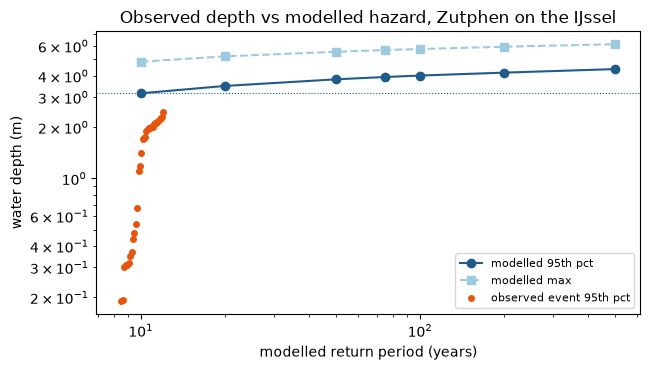

In [7]:
obs_p95 = np.sort(obs["p95_depth_m"].to_numpy())
x_obs = np.linspace(8.5, 12.0, obs_p95.size)  # spread near RP10, for visibility only

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(rp["return_period"], rp["p95_depth_m"], "o-", color="#1f5c8b", label="modelled 95th pct")
ax.plot(rp["return_period"], rp["max_depth_m"], "s--", color="#9ecae1", label="modelled max")
ax.scatter(x_obs, obs_p95, s=16, color="#e6550d", zorder=5, label="observed event 95th pct")
ax.axhline(float(rp.loc[0, "p95_depth_m"]), color="#1f5c8b", ls=":", lw=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("modelled return period (years)")
ax.set_ylabel("water depth (m)")
ax.set_title("Observed depth vs modelled hazard, Zutphen on the IJssel")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

In [8]:
rp10_p95 = float(rp.loc[rp["return_period"] == 10, "p95_depth_m"].iloc[0])
rp10_max = float(rp.loc[rp["return_period"] == 10, "max_depth_m"].iloc[0])
rp100_max = float(rp.loc[rp["return_period"] == 100, "max_depth_m"].iloc[0])
print(f"all observed 95th-pct depths <= RP10 95th-pct ({rp10_p95:.2f} m): "
      f"{bool((obs['p95_depth_m'] <= rp10_p95).all())}")
print(f"events whose maximum exceeds the modelled RP10 max ({rp10_max:.1f} m): "
      f"{int((obs['max_depth_m'] > rp10_max).sum())} of {len(obs)}")
print(f"events whose maximum exceeds the modelled RP100 max ({rp100_max:.1f} m): "
      f"{int((obs['max_depth_m'] > rp100_max).sum())} of {len(obs)}")

all observed 95th-pct depths <= RP10 95th-pct (3.16 m): True
events whose maximum exceeds the modelled RP10 max (4.8 m): 9 of 33
events whose maximum exceeds the modelled RP100 max (5.8 m): 2 of 33


Every observed event 95th-percentile depth lies **at or below** the modelled RP10 95th
percentile. A few events do contain a *local* maximum deeper than the modelled RP100 maximum:
the 95th percentile describes broadly elevated depths across a footprint, whereas the maximum
can be a single highly localised peak. Broadly, the observed events show shallower water spread
across the floodplain, while the undefended fluvial hazard scenarios concentrate depth in the
channel.

In [9]:
# Key figures, computed from the results above.
# Derive the span from the data so the label can never contradict the count.
_span = f"{cat['date'].astype(str).str[:4].min()} to {cat['end_date'].astype(str).str[:4].max()}"
deepest = obs.sort_values("max_depth_m", ascending=False).iloc[0]
Markdown(
    f"### Key figures\n"
    f"| | |\n|---|---|\n"
    f"| **Events at this reach ({_span})** | **{len(cat)}** |\n"
    f"| **Max detections in one cell** | **{int(counts.max())}** |\n"
    f"| **Median event 95th-pct depth** | **{obs['p95_depth_m'].median():.2f} m** |\n"
    f"| **Deepest event** | **{deepest['max_depth_m']:.1f} m** ({deepest['date']}) |\n"
    f"| **Modelled RP10 95th-pct depth** | **{rp10_p95:.2f} m** |\n"
)

### Key figures
| | |
|---|---|
| **Events at this reach (2015 to 2025)** | **33** |
| **Max detections in one cell** | **26** |
| **Median event 95th-pct depth** | **1.73 m** |
| **Deepest event** | **6.8 m** (2018-01-22) |
| **Modelled RP10 95th-pct depth** | **3.16 m** |


## Zoom in: the deepest event (22 January 2018)

The 20 m depth raster for a single event, read as a `DepthRaster` and shown interactively on
the grey basemap. This is the deepest event in the record; zoom in to see depth along the
IJssel channel and across the floodplain.


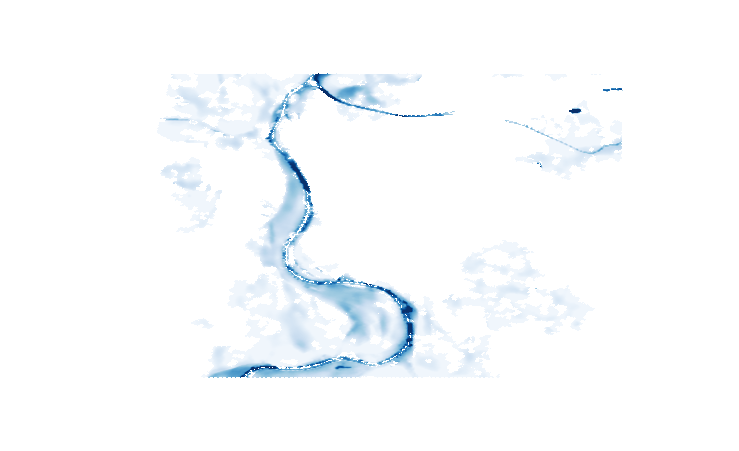

In [10]:
deepest_path = dl.loc[dl["event_id"] == deepest["event_id"], "path"].iloc[0]
ef.open_depth(deepest_path).explore(tiles="grayscale", vmax=3.0)

## The published figure

The multi-panel Fig. S4 (per-cell recurrence, the per-event 95th-percentile to maximum depth
segments, and the observed depths placed on the modelled return-period curve) is assembled by
the paper's figure script from the same queries above, shown here for comparison.

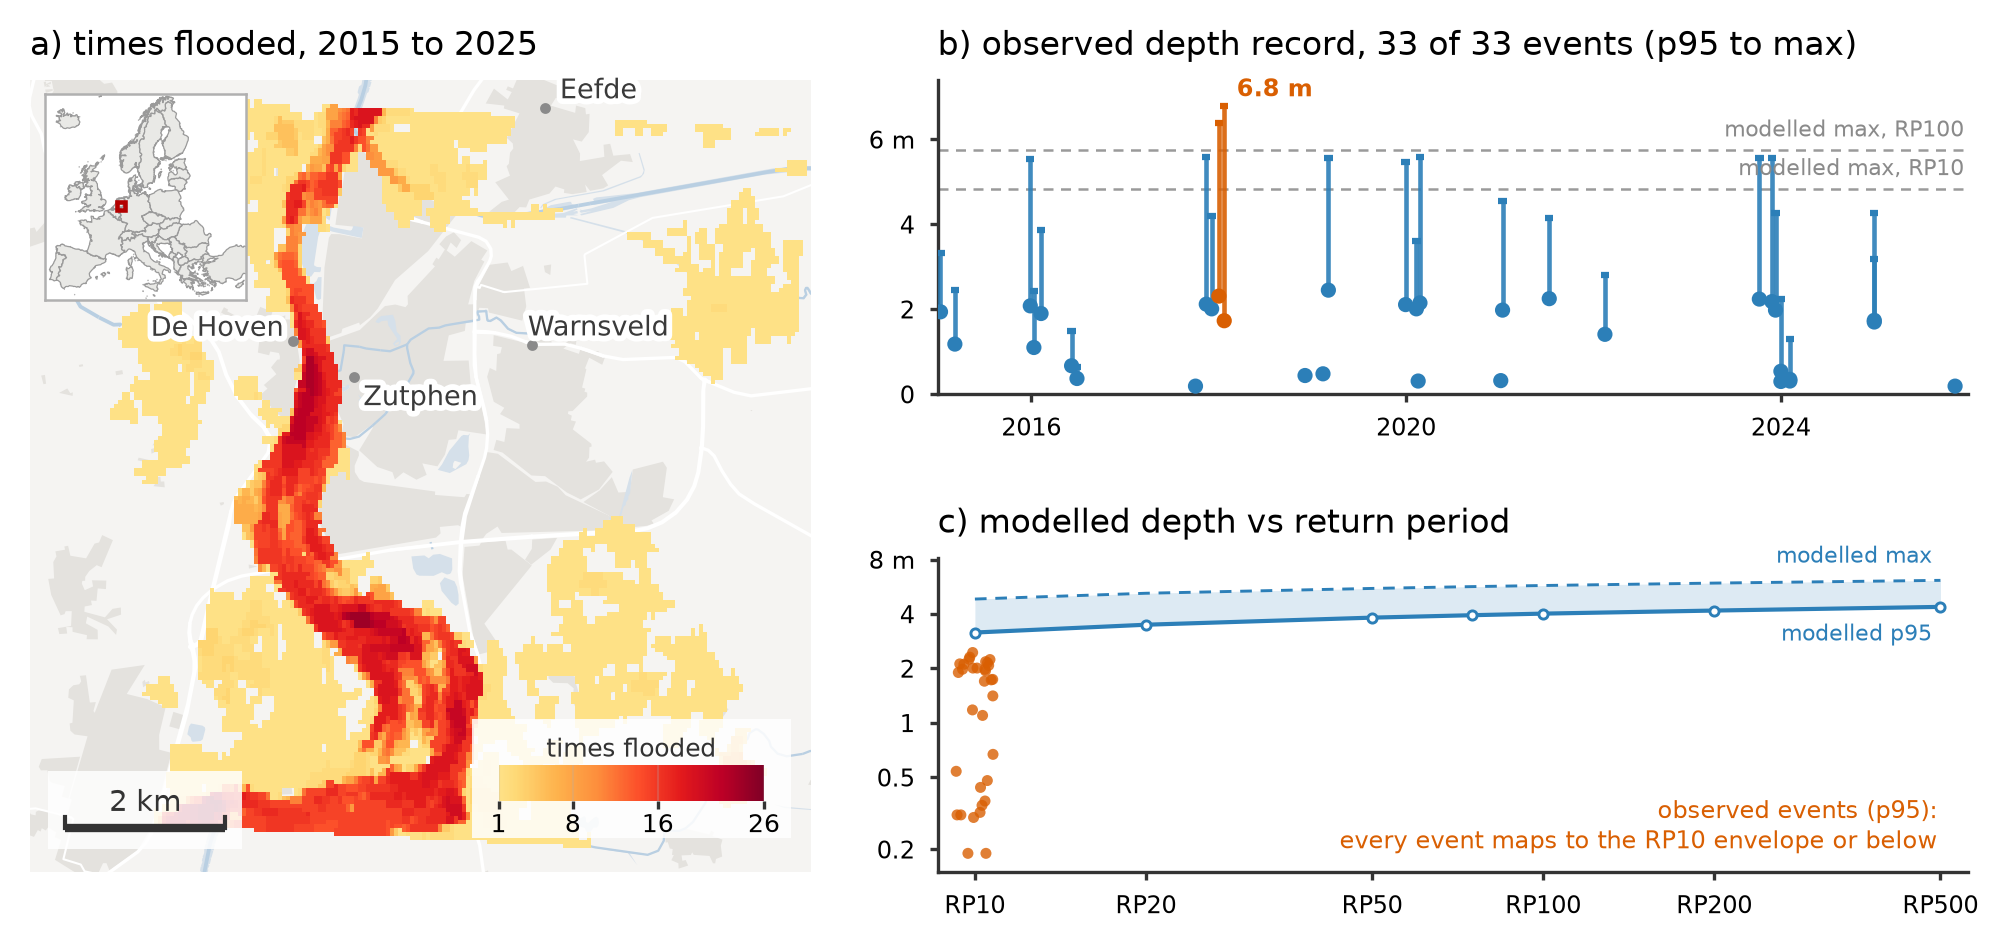

In [11]:
S.published_figure("zutphen-multi")

## Interpretation

This is a **diagnostic screening**, not a validation of the hazard maps or an estimate of flood
frequency. Three points matter:

1. **Recurrence is a detection count.** It records archived event detections, not statistically
   independent floods, and cannot be converted into annual exceedance probabilities or return
   periods. A ten-year record is also too short to estimate the RP50 to RP500 scenarios.
2. **The observed points carry no return period.** Their placement near RP10 in the chart is
   for visibility only; it does not assign a frequency to the events.
3. **Observed and modelled are different estimators over different extents.** Observed depths
   are reconstructed from Sentinel-1 and terrain, may omit water the sensor did not see, and
   carry decimetre-scale uncertainty; the CEMS-GLOFAS scenarios are undefended and fluvial only.

The main text (Section 7.2, Fig. 6) complements this with the *spatial* comparison at the same
reach: of the cells observed wet at least once, 82.4% fall within the modelled RP10 extent and
17.6% lie outside it, a fraction that falls to 5.2% at RP500 but never reaches zero.

## References and reuse

This notebook reproduces the Zutphen case study (Supplementary Material, Section S1.4, Fig. S4;
see also main text Section 7.2, Fig. 6) of:

> J. Hackl (2026). *EuroFlood: a Python library and queryable index for the CEMS
> satellite-derived flood-depth archive of Europe.*